In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from tqdm.auto import tqdm

from dt.model   import DecisionTransformer
from dt.dataset import SequenceDataset
from sim.env    import DiffDriveEnv

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

DATA_DIR    = '../data'
CKPT_DIR    = '../checkpoints'
DATASETS    = ['1k', '2k', '5k', '10k']
N_EVAL      = 200
DESIRED_RTG = -0.25
MAX_STEPS   = 1000

MODEL_CFG = dict(
    obs_dim=3, act_dim=2, embed_dim=64, n_heads=4,
    n_layers=3, dropout=0.1, context_len=20, max_timestep=1000,
)

c:\GitHub\Skoltech courses\DL\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
def rollout_batched(model, dataset, n_episodes, desired_rtg, max_steps, batch_size=64):
    """Runs batch_size episodes in parallel. Trajectory stores [x, y, theta] per step."""
    model.eval()
    K        = model.context_len
    obs_dim  = dataset.obs_mean.shape[0]
    act_dim  = dataset.act_mean.shape[0]
    rtg_init = desired_rtg / dataset.rtg_scale
    rtg_step = 1.0 / dataset.rtg_scale

    obs_mean = torch.from_numpy(dataset.obs_mean).to(device)
    obs_std  = torch.from_numpy(dataset.obs_std).to(device)
    act_mean = torch.from_numpy(dataset.act_mean).to(device)
    act_std  = torch.from_numpy(dataset.act_std).to(device)

    trajs     = []
    pbar      = tqdm(total=n_episodes, desc='rollout', leave=False)
    remaining = n_episodes

    while remaining > 0:
        B    = min(batch_size, remaining)
        envs = [DiffDriveEnv() for _ in range(B)]

        obs_np   = np.array([env.reset() for env in envs], dtype=np.float32)
        xyt_trajs = [[[env.x, env.y, np.arctan2(env.sin_theta, env.cos_theta)]] for env in envs]
        done_arr = np.zeros(B, dtype=bool)

        obs_buf = torch.zeros(B, K, obs_dim, device=device)
        act_buf = torch.zeros(B, K, act_dim, device=device)
        rtg_buf = torch.zeros(B, K, 1, device=device)
        ts_buf  = torch.zeros(B, K, dtype=torch.long, device=device)
        rtg_cur = torch.full((B,), rtg_init, device=device)

        with torch.no_grad():
            for step in range(max_steps):
                if done_arr.all():
                    break

                obs_t    = torch.from_numpy(obs_np).to(device)
                obs_norm = (obs_t - obs_mean) / obs_std

                obs_buf = torch.roll(obs_buf, -1, dims=1)
                act_buf = torch.roll(act_buf, -1, dims=1)
                rtg_buf = torch.roll(rtg_buf, -1, dims=1)
                ts_buf  = torch.roll(ts_buf,  -1, dims=1)

                obs_buf[:, -1]    = obs_norm
                rtg_buf[:, -1, 0] = rtg_cur
                ts_buf[:, -1]     = min(step, 999)

                pred        = model(obs_buf, act_buf, rtg_buf, ts_buf)
                action_norm = pred[:, -1]
                act_buf[:, -1] = action_norm

                actions  = (action_norm * act_std + act_mean).cpu().numpy()
                rtg_cur += rtg_step

                new_obs = obs_np.copy()
                for i in range(B):
                    if done_arr[i]:
                        continue
                    obs_i, done_i = envs[i].step(actions[i])
                    new_obs[i] = obs_i
                    xyt_trajs[i].append([envs[i].x, envs[i].y,
                                         np.arctan2(envs[i].sin_theta, envs[i].cos_theta)])
                    if done_i:
                        done_arr[i] = True
                obs_np = new_obs

        for i in range(B):
            trajs.append((np.array(xyt_trajs[i], dtype=np.float32), bool(done_arr[i])))

        remaining -= B
        pbar.update(B)

    pbar.close()
    model.train()
    return trajs

In [3]:
all_results = {}

for key in DATASETS:
    ckpt_path = f'{CKPT_DIR}/dt_{key}_best.pt'
    if not os.path.exists(ckpt_path):
        print(f'{key}: checkpoint not found — skipping')
        continue

    print(f'\n=== {key} ===')
    dataset = SequenceDataset(
        f'{DATA_DIR}/dataset_{key}.h5',
        context_len=MODEL_CFG['context_len'],
        samples_per_traj=1,
    )

    model = DecisionTransformer(**MODEL_CFG).to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))

    trajs = rollout_batched(model, dataset, N_EVAL, DESIRED_RTG, MAX_STEPS, batch_size=N_EVAL)

    sr  = sum(1 for _, d in trajs if d) / N_EVAL
    ml  = float(np.mean([len(xy) for xy, _ in trajs]))
    all_results[key] = {'trajs': trajs, 'success_rate': sr, 'mean_length': ml}
    print(f'  SR={sr:.1%}  mean_len={ml:.0f}')


=== 1k ===


c:\GitHub\Skoltech courses\DL\project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  SR=99.0%  mean_len=321

=== 2k ===


c:\GitHub\Skoltech courses\DL\project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  SR=89.0%  mean_len=340

=== 5k ===


  SR=89.5%  mean_len=444

=== 10k ===


  SR=89.5%  mean_len=473


In [4]:
print(f"{'dataset':>8}  {'SR':>7}  {'mean_len':>9}  {'failed':>7}")
print('-' * 38)
for key, r in all_results.items():
    failed = sum(1 for _, d in r['trajs'] if not d)
    print(f"  {key:>6}  {r['success_rate']:>7.1%}  {r['mean_length']:>9.0f}  {failed:>7}")

 dataset       SR   mean_len   failed
--------------------------------------
      1k    99.0%        321        2
      2k    89.0%        340       22
      5k    89.5%        444       21
     10k    89.5%        473       21


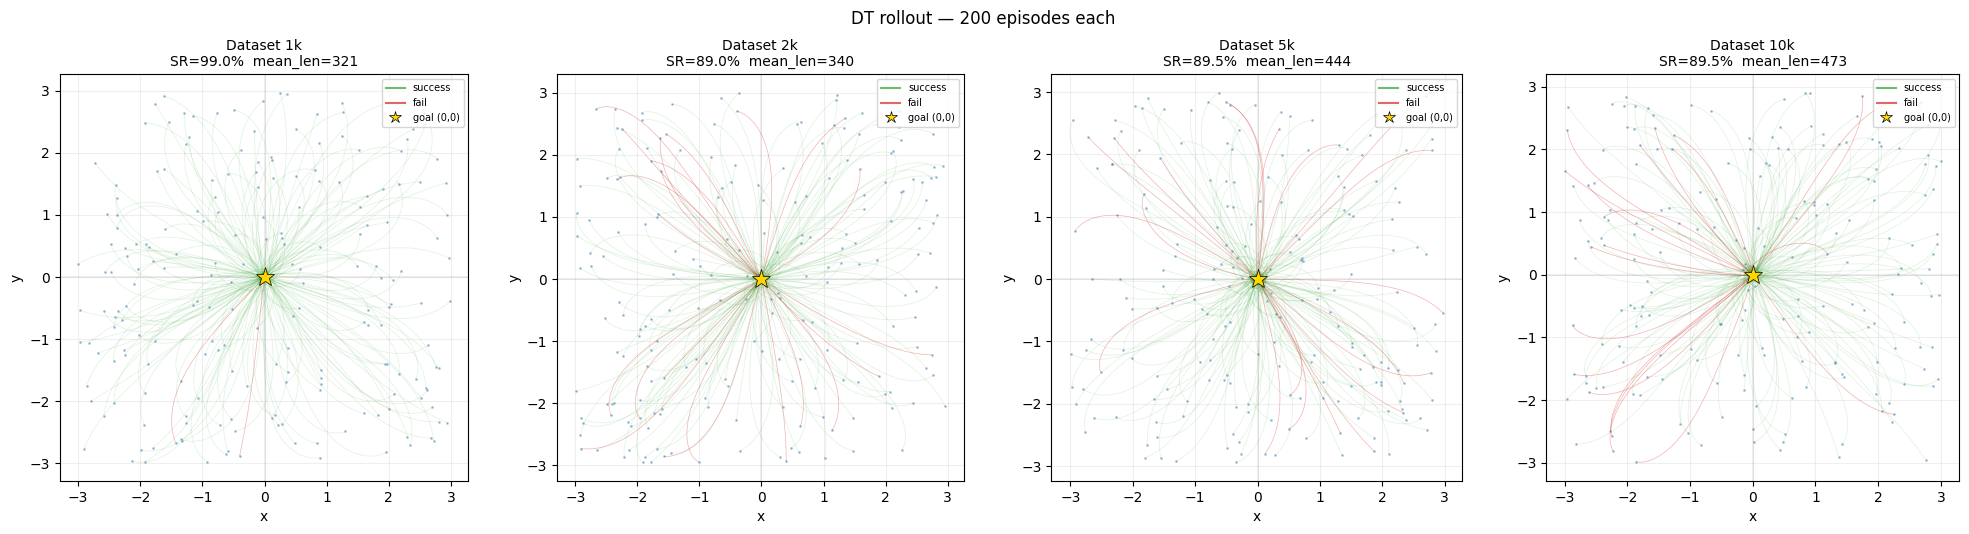

Saved → ../eval_trajectories.png


In [5]:
n_plots = len(all_results)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), squeeze=False)
axes = axes[0]

for ax, (key, r) in zip(axes, all_results.items()):
    for xyt, success in r['trajs']:
        xy    = xyt[:, :2]
        color = '#2ca02c' if success else '#d62728'
        alpha = 0.12      if success else 0.35
        lw    = 0.6       if success else 0.5
        ax.plot(xy[:, 0], xy[:, 1], color=color, alpha=alpha, lw=lw)
        ax.plot(xy[0, 0], xy[0, 1], '.', color='steelblue', markersize=2, alpha=0.4)

    ax.plot(0, 0, '*', color='gold', markersize=14, zorder=5, markeredgecolor='k', markeredgewidth=0.5)

    sr  = r['success_rate']
    ml  = r['mean_length']
    ax.set_title(f'Dataset {key}\nSR={sr:.1%}  mean_len={ml:.0f}', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(0, color='k', lw=0.3, alpha=0.3)
    ax.axvline(0, color='k', lw=0.3, alpha=0.3)

    ok_line   = mlines.Line2D([], [], color='#2ca02c', alpha=0.7, lw=1.5, label='success')
    fail_line = mlines.Line2D([], [], color='#d62728', alpha=0.7, lw=1.5, label='fail')
    goal_pt   = mlines.Line2D([], [], marker='*', color='gold', markersize=9,
                               markeredgecolor='k', markeredgewidth=0.5,
                               linestyle='none', label='goal (0,0)')
    ax.legend(handles=[ok_line, fail_line, goal_pt], fontsize=7, loc='upper right')

plt.suptitle(f'DT rollout — {N_EVAL} episodes each', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../eval_trajectories.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → ../eval_trajectories.png')

In [6]:
from sim.expert import ExpertController

expert     = ExpertController()
expert_env = DiffDriveEnv()
expert_trajs = []

for _ in tqdm(range(N_EVAL), desc='expert rollout'):
    obs  = expert_env.reset()
    xyt  = [[expert_env.x, expert_env.y,
              np.arctan2(expert_env.sin_theta, expert_env.cos_theta)]]
    done = False
    for _ in range(MAX_STEPS):
        state  = expert_env.get_state()
        action = expert.act(obs, state)
        obs, done = expert_env.step(action)
        xyt.append([expert_env.x, expert_env.y,
                    np.arctan2(expert_env.sin_theta, expert_env.cos_theta)])
        if done:
            break
    expert_trajs.append((np.array(xyt, dtype=np.float32), done))

sr = sum(1 for _, d in expert_trajs if d) / N_EVAL
ml = float(np.mean([len(xyt) for xyt, _ in expert_trajs]))
print(f'Expert: SR={sr:.1%}  mean_len={ml:.0f}')

expert rollout: 100%|██████████| 200/200 [00:00<00:00, 368.13it/s]

Expert: SR=99.5%  mean_len=182


C:\Users\vladi\AppData\Local\Temp\ipykernel_37284\1967757194.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[k] for k in labels], labels=labels,
C:\Users\vladi\AppData\Local\Temp\ipykernel_37284\1967757194.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data[k] for k in labels], labels=labels,


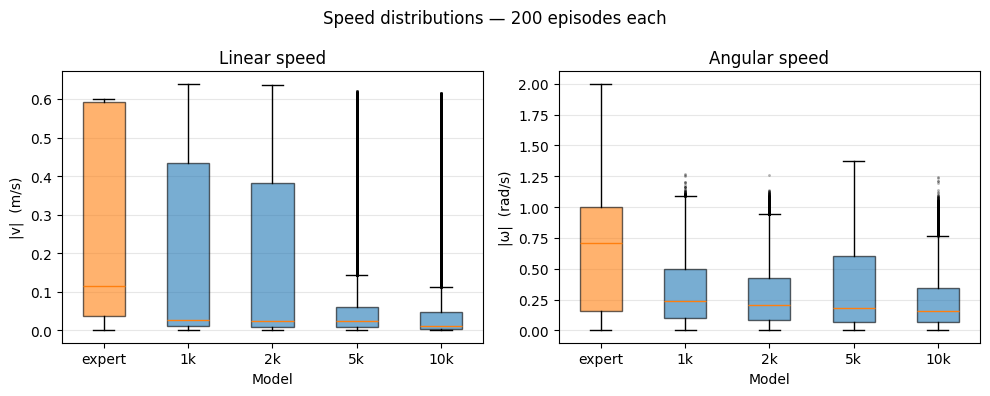

Saved → ../eval_speed_boxplot.png


In [7]:
ENV_DT = 0.05

# собираем данные: сначала эксперт, потом DT модели
all_speed = {'expert': expert_trajs}
all_speed.update({k: r['trajs'] for k, r in all_results.items()})

lin_data = {}
ang_data = {}
for label, trajs in all_speed.items():
    lin, ang = [], []
    for xyt, _ in trajs:
        if len(xyt) < 2:
            continue
        disp   = np.linalg.norm(np.diff(xyt[:, :2], axis=0), axis=1)
        lin.extend(disp / ENV_DT)
        dtheta = np.diff(xyt[:, 2])
        dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi
        ang.extend(np.abs(dtheta) / ENV_DT)
    lin_data[label] = lin
    ang_data[label]  = ang

labels = list(lin_data.keys())
colors = ['tab:orange'] + ['tab:blue'] * (len(labels) - 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, ylabel, title in [
    (axes[0], lin_data, '|v|  (m/s)',   'Linear speed'),
    (axes[1], ang_data, '|ω|  (rad/s)', 'Angular speed'),
]:
    bp = ax.boxplot([data[k] for k in labels], labels=labels,
                    patch_artist=True,
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_xlabel('Model')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'Speed distributions — {N_EVAL} episodes each', fontsize=12)
plt.tight_layout()
plt.savefig('../eval_speed_boxplot.png', dpi=130)
plt.show()
print('Saved → ../eval_speed_boxplot.png')